# 03 – Alimentación a Parquet

Este notebook procesa el archivo:

`../data/raw/sobrantes y dietas 2025.xlsx`

y construye datasets estructurados para integrarlos más adelante al pipeline principal.

## Objetivos

- leer las hojas mensuales de alimentación
- normalizar columnas y fechas
- construir un dataset diario por corral
- leer correctamente las hojas de dieta por periodo
- documentar la vigencia correcta de cada dieta
- exportar resultados a parquet

## Aclaración importante sobre las hojas de dieta

La interpretación correcta del archivo es:

- **`dieta Mayo`** corresponde al periodo **enero a mayo**
- **`Dieta Junio`** corresponde al periodo **junio a julio**
- **`Dieta Agosto`** corresponde al periodo **agosto a septiembre**

Es decir, los nombres de esas hojas no indican un solo mes, sino el **inicio o referencia del periodo de dieta vigente**.


## 1. Importaciones


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", None)


## 2. Rutas del proyecto


In [2]:

INPUT_PATH = "../data/raw/dieta/sobrantes y dietas 2025.xlsx"

OUT_FEEDING = "../data/interim/feeding_daily_corral.parquet"
OUT_DIETS = "../data/interim/diet_periods.parquet"
OUT_DIET_SUMMARY = "../data/interim/diet_period_summary.parquet"

print("Archivo de entrada:", INPUT_PATH)


Archivo de entrada: ../data/raw/dieta/sobrantes y dietas 2025.xlsx


## 3. Inspección de hojas disponibles


In [3]:
xls = pd.ExcelFile(INPUT_PATH)

print("Hojas disponibles:")
display(pd.DataFrame({"sheet_name": xls.sheet_names}))


Hojas disponibles:


,sheet_name
0,Enero
1,Febrero
2,Marzo
3,Abril
4,Mayo
5,Junio
6,Julio
7,Agosto
8,Septiembre
9,dieta Mayo


## 4. Definición de hojas mensuales y hojas de dieta

Las hojas mensuales contienen observaciones diarias.  
Las hojas de dieta contienen la composición vigente por periodo.


In [4]:
monthly_sheets = [
    "Enero ", "Febrero", "Marzo", "Abril", "Mayo",
    "Junio", "Julio", "Agosto", "Septiembre"
]

diet_periods_map = {
    "dieta Mayo":   ("2025-01-01", "2025-05-31"),
    "Dieta Junio":  ("2025-06-01", "2025-07-31"),
    "Dieta Agosto": ("2025-08-01", "2025-09-30"),
}

print("Hojas mensuales:")
print(monthly_sheets)

print("\nHojas de dieta y vigencia:")
for k, v in diet_periods_map.items():
    print(k, "->", v)


Hojas mensuales:
['Enero ', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre']

Hojas de dieta y vigencia:
dieta Mayo -> ('2025-01-01', '2025-05-31')
Dieta Junio -> ('2025-06-01', '2025-07-31')
Dieta Agosto -> ('2025-08-01', '2025-09-30')


## 5. Funciones auxiliares

Se definen funciones para:

- limpiar nombres de columnas
- detectar encabezados en hojas mensuales
- detectar el encabezado real en hojas de dieta
- homogeneizar nombres de columnas


In [5]:
def clean_columns(cols):
    s = pd.Index(cols).astype(str)
    s = (
        s.str.strip()
         .str.lower()
         .str.replace("\n", " ", regex=False)
         .str.replace(r"\s+", " ", regex=True)
         .str.replace(" ", "_", regex=False)
         .str.replace("°", "n", regex=False)
         .str.replace("º", "n", regex=False)
         .str.replace("%", "pct", regex=False)
         .str.replace("/", "_", regex=False)
         .str.replace(".", "", regex=False)
         .str.replace("-", "_", regex=False)
         .str.replace("__", "_", regex=False)
    )
    return list(s)

def first_existing(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def is_effectively_blank(value):
    if pd.isna(value):
        return True
    s = str(value).strip().lower()
    return s in {"", "nan", "nat", "none"}

def parse_monthly_sheet(file_path, sheet_name):
    raw = pd.read_excel(file_path, sheet_name=sheet_name, header=None)

    header_idx = None
    for i, row in raw.iterrows():
        vals = [str(x).strip().lower() for x in row.tolist()]
        if any("fecha" in v for v in vals) and any("corral" in v for v in vals):
            header_idx = i
            break

    if header_idx is None:
        raise ValueError(f"No se encontró la fila de encabezado real en la hoja: {sheet_name}")

    headers = clean_columns(raw.iloc[header_idx].fillna("").tolist())
    df = raw.iloc[header_idx + 1:].copy()
    df.columns = headers

    df = df.loc[:, [c for c in df.columns if c not in ["", "nan"]]]

    rename_map = {}
    for c in df.columns:
        if c.startswith("fecha"):
            rename_map[c] = "fecha"
        elif c.startswith("corrales") or c.startswith("corral"):
            rename_map[c] = "corral"
        elif c in ["sobrante", "sobrante_"]:
            rename_map[c] = "sobrante"
        elif c in ["consumo", "consumo_"]:
            rename_map[c] = "consumo"
        elif c in ["rechazo", "pct_rechazo", "_rechazo"]:
            rename_map[c] = "rechazo"

    df = df.rename(columns=rename_map)

    if "fecha" not in df.columns or "corral" not in df.columns:
        raise ValueError(f"No se detectaron columnas mínimas en {sheet_name}")

    # Preservar la fecha cruda antes de cualquier parseo.
    # En varias hojas Excel mezcla timestamps reales con strings tipo 25-07-02.
    # Si hacemos pd.to_datetime() aquí, perdemos contexto y se inducen errores.
    df["fecha"] = df["fecha"].where(~df["fecha"].apply(is_effectively_blank), np.nan).ffill()

    df["corral_num"] = pd.to_numeric(df["corral"], errors="coerce")
    df = df[df["corral_num"].notna()].copy()
    df["corral"] = df["corral_num"].astype(int)
    df.drop(columns=["corral_num"], inplace=True)

    numeric_cols = ["kg_am", "kg_pm", "kg_totales", "sobrante", "consumo", "rechazo"]
    for c in numeric_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    if {"kg_am", "kg_pm"}.issubset(df.columns):
        kg_totales_calc = df["kg_am"].fillna(0) + df["kg_pm"].fillna(0)
        if "kg_totales" not in df.columns:
            df["kg_totales"] = kg_totales_calc
        else:
            df["kg_totales"] = df["kg_totales"].fillna(kg_totales_calc)

    if "sobrante" not in df.columns:
        df["sobrante"] = np.nan
    if "consumo" not in df.columns:
        df["consumo"] = np.nan
    if "rechazo" not in df.columns:
        df["rechazo"] = np.nan

    mask_sobrante = df["sobrante"].isna() & df["consumo"].notna() & df["kg_totales"].notna()
    df.loc[mask_sobrante, "sobrante"] = df.loc[mask_sobrante, "kg_totales"] - df.loc[mask_sobrante, "consumo"]

    mask_consumo = df["consumo"].isna() & df["sobrante"].notna() & df["kg_totales"].notna()
    df.loc[mask_consumo, "consumo"] = df.loc[mask_consumo, "kg_totales"] - df.loc[mask_consumo, "sobrante"]

    df["sobrante"] = df["sobrante"].fillna(0)
    df["consumo"] = df["consumo"].fillna(df["kg_totales"] - df["sobrante"])

    zero_total_mask = df["kg_totales"].fillna(0).eq(0)
    df.loc[zero_total_mask & df["kg_am"].isna(), "kg_am"] = 0
    df.loc[zero_total_mask & df["kg_pm"].isna(), "kg_pm"] = 0

    rechazo_calc = df["sobrante"] / df["kg_totales"].replace(0, np.nan)
    df["rechazo"] = pd.to_numeric(df["rechazo"], errors="coerce")
    df["rechazo"] = df["rechazo"].where(df["rechazo"].between(0, 1), np.nan)
    df["rechazo"] = df["rechazo"].fillna(rechazo_calc).fillna(0)

    df = df[["fecha", "corral", "kg_am", "kg_pm", "kg_totales", "sobrante", "consumo", "rechazo"]].copy()
    df = df.rename(columns={"fecha": "date_raw"})
    df["sheet_name"] = sheet_name.strip()

    return df.reset_index(drop=True), header_idx

def parse_diet_sheet(file_path, sheet_name, start_date, end_date):
    raw = pd.read_excel(file_path, sheet_name=sheet_name, header=None)

    header_idx = None
    for i, row in raw.iterrows():
        row_str = row.astype(str).str.strip().str.upper().tolist()
        if "INGREDIENTES" in row_str:
            header_idx = i
            break

    if header_idx is None:
        raise ValueError(f"No se encontró la fila de encabezado real en la hoja: {sheet_name}")

    data = raw.iloc[header_idx + 1:, :5].copy()
    data.columns = ["ingrediente", "pct_ms", "kg_humeda", "kg_seca", "kg_am_pm"]

    data["ingrediente"] = data["ingrediente"].astype(str).str.strip()
    data = data[data["ingrediente"].notna()]
    data = data[~data["ingrediente"].str.lower().isin(["nan", "none", ""])]
    data = data[~data["ingrediente"].str.contains("total", case=False, na=False)]

    for c in ["pct_ms", "kg_humeda", "kg_seca", "kg_am_pm"]:
        data[c] = pd.to_numeric(data[c], errors="coerce")

    data = data[~(data[["pct_ms", "kg_humeda", "kg_seca", "kg_am_pm"]].isna().all(axis=1))].copy()

    consumo_kg_vaca = pd.to_numeric(raw.iloc[header_idx - 2, 4], errors="coerce") if header_idx >= 2 else np.nan
    am_pm_fraction = pd.to_numeric(raw.iloc[header_idx, 4], errors="coerce")

    data["diet_period"] = sheet_name
    data["period_start"] = pd.to_datetime(start_date)
    data["period_end"] = pd.to_datetime(end_date)
    data["consumo_kg_vaca"] = consumo_kg_vaca
    data["am_pm_fraction"] = am_pm_fraction

    data = data[
        ["ingrediente", "pct_ms", "kg_humeda", "kg_seca", "kg_am_pm",
         "diet_period", "period_start", "period_end", "consumo_kg_vaca", "am_pm_fraction"]
    ].reset_index(drop=True)

    return data, header_idx

## 6. Lectura de hojas mensuales de alimentación

Aquí se construye un dataframe diario por corral a partir de las hojas:

- Enero
- Febrero
- Marzo
- Abril
- Mayo
- Junio
- Julio
- Agosto
- Septiembre


In [6]:
feeding_frames = []
sheet_debug = []

for sheet in monthly_sheets:
    df, header_idx = parse_monthly_sheet(INPUT_PATH, sheet)

    feeding_frames.append(df)

    sheet_debug.append({
        "sheet": sheet,
        "header_idx": header_idx,
        "rows": len(df),
        "date_raw_examples": df["date_raw"].dropna().astype(str).head(5).tolist(),
        "corrales": sorted(df["corral"].dropna().unique().tolist()),
        "columns": ", ".join(df.columns)
    })

sheet_debug_df = pd.DataFrame(sheet_debug)
display(sheet_debug_df)

feeding_daily_corral = pd.concat(feeding_frames, ignore_index=True).copy()

print("Shape feeding_daily_corral:", feeding_daily_corral.shape)
print("Tipo original de la columna 'date_raw':", feeding_daily_corral["date_raw"].dtype)
display(feeding_daily_corral.head(20))
display(feeding_daily_corral.tail(20))

,sheet,header_idx,rows,date_raw_examples,corrales,columns
0,Enero,1,186,"[2025-01-01 00:00:00, 2025-01-01 00:00:00, 202...","[1, 2, 3, 4, 5, 6]","date_raw, corral, kg_am, kg_pm, kg_totales, so..."
1,Febrero,1,168,"[2025-02-01 00:00:00, 2025-02-01 00:00:00, 202...","[1, 2, 3, 4, 5, 6]","date_raw, corral, kg_am, kg_pm, kg_totales, so..."
2,Marzo,1,186,"[2025-03-01 00:00:00, 2025-03-01 00:00:00, 202...","[1, 2, 3, 4, 5, 6]","date_raw, corral, kg_am, kg_pm, kg_totales, so..."
3,Abril,1,180,"[2025-04-01 00:00:00, 2025-04-01 00:00:00, 202...","[1, 2, 3, 4, 5, 6]","date_raw, corral, kg_am, kg_pm, kg_totales, so..."
4,Mayo,1,186,"[2025-05-01 00:00:00, 2025-05-01 00:00:00, 202...","[1, 2, 3, 4, 5, 6]","date_raw, corral, kg_am, kg_pm, kg_totales, so..."
5,Junio,1,180,"[2025-06-01 00:00:00, 2025-06-01 00:00:00, 202...","[1, 2, 3, 4, 5, 6]","date_raw, corral, kg_am, kg_pm, kg_totales, so..."
6,Julio,3,186,"[2025-07-01 00:00:00, 2025-07-01 00:00:00, 202...","[1, 2, 3, 4, 5, 6]","date_raw, corral, kg_am, kg_pm, kg_totales, so..."
7,Agosto,3,186,"[2025-08-01 00:00:00, 2025-08-01 00:00:00, 202...","[1, 2, 3, 4, 5, 6]","date_raw, corral, kg_am, kg_pm, kg_totales, so..."
8,Septiembre,3,180,"[2025-09-01 00:00:00, 2025-09-01 00:00:00, 202...","[1, 2, 3, 4, 5, 6]","date_raw, corral, kg_am, kg_pm, kg_totales, so..."


Shape feeding_daily_corral: (1638, 9)
Tipo original de la columna 'date_raw': object


,date_raw,corral,kg_am,kg_pm,kg_totales,sobrante,consumo,rechazo,sheet_name
0,2025-01-01 00:00:00,1,500.0,500.0,1000,0.0,1000,0.000000,Enero
1,2025-01-01 00:00:00,2,650.0,650.0,1300,0.0,1300,0.000000,Enero
2,2025-01-01 00:00:00,3,600.0,600.0,1200,0.0,1200,0.000000,Enero
3,2025-01-01 00:00:00,4,650.0,650.0,1300,10.0,1290,0.007692,Enero
4,2025-01-01 00:00:00,5,600.0,600.0,1200,0.0,1200,0.000000,Enero
5,2025-01-01 00:00:00,6,1000.0,1000.0,2000,0.0,2000,0.000000,Enero
6,2025-01-02 00:00:00,1,550.0,550.0,1100,110.0,990,0.100000,Enero
7,2025-01-02 00:00:00,2,650.0,650.0,1300,130.0,1170,0.100000,Enero
8,2025-01-02 00:00:00,3,600.0,600.0,1200,80.0,1120,0.066667,Enero
9,2025-01-02 00:00:00,4,650.0,650.0,1300,220.0,1080,0.169231,Enero


,date_raw,corral,kg_am,kg_pm,kg_totales,sobrante,consumo,rechazo,sheet_name
1618,2025-09-27 00:00:00,5,0.0,0.0,0,0.0,0,0.0,Septiembre
1619,2025-09-27 00:00:00,6,0.0,0.0,0,0.0,0,0.0,Septiembre
1620,2025-09-28 00:00:00,1,0.0,0.0,0,0.0,0,0.0,Septiembre
1621,2025-09-28 00:00:00,2,0.0,0.0,0,0.0,0,0.0,Septiembre
1622,2025-09-28 00:00:00,3,0.0,0.0,0,0.0,0,0.0,Septiembre
1623,2025-09-28 00:00:00,4,0.0,0.0,0,0.0,0,0.0,Septiembre
1624,2025-09-28 00:00:00,5,0.0,0.0,0,0.0,0,0.0,Septiembre
1625,2025-09-28 00:00:00,6,0.0,0.0,0,0.0,0,0.0,Septiembre
1626,2025-09-29 00:00:00,1,0.0,0.0,0,0.0,0,0.0,Septiembre
1627,2025-09-29 00:00:00,2,0.0,0.0,0,0.0,0,0.0,Septiembre


In [7]:

import datetime
import re

month_map = {
    "enero": 1,
    "febrero": 2,
    "marzo": 3,
    "abril": 4,
    "mayo": 5,
    "junio": 6,
    "julio": 7,
    "agosto": 8,
    "septiembre": 9,
    "setiembre": 9,
    "octubre": 10,
    "noviembre": 11,
    "diciembre": 12,
}

def _safe_ts(year, month, day):
    try:
        return pd.Timestamp(year=int(year), month=int(month), day=int(day)).normalize()
    except Exception:
        return None

def parse_feeding_date(value, sheet_name=None):
    """
    Normaliza fechas heterogéneas sin asumir un único formato.

    Prioridades:
    1) Si Excel ya entregó datetime real, se conserva.
    2) Si son 3 números separados por '-' o '/', se generan candidatos:
       - yyyy-mm-dd
       - yyyy-dd-mm
       - yy-mm-dd
       - yy-dd-mm
       - dd-mm-yy
       - mm-dd-yy
    3) Se prioriza el candidato cuyo mes coincide con la hoja.
    4) Si existe un candidato con año 2025, se prioriza porque todo este dataset
       corresponde a 2025.
    5) Sólo al final se usa pd.to_datetime como respaldo.
    """
    if pd.isna(value):
        return pd.NaT

    sheet_month = month_map.get(str(sheet_name).strip().lower(), None)

    if isinstance(value, (pd.Timestamp, datetime.datetime, datetime.date)):
        return pd.Timestamp(value).normalize()

    s = str(value).strip()
    if s == "" or s.lower() in {"nan", "nat", "none"}:
        return pd.NaT

    parts = re.split(r"[-/]", s)
    if len(parts) == 3 and all(p.strip().isdigit() for p in parts):
        a, b, c = [int(p) for p in parts]
        candidates = []

        def add(ts):
            if ts is not None and ts not in candidates:
                candidates.append(ts)

        if a >= 1000:
            add(_safe_ts(a, b, c))  # yyyy-mm-dd
            add(_safe_ts(a, c, b))  # yyyy-dd-mm
        else:
            # Interpretaciones con año de 2 dígitos al inicio
            year_a = 2000 + a if a < 100 else a
            add(_safe_ts(year_a, b, c))  # yy-mm-dd
            add(_safe_ts(year_a, c, b))  # yy-dd-mm

            # Interpretaciones con año de 2 dígitos al final
            year_c = 2000 + c if c < 100 else c
            add(_safe_ts(year_c, b, a))  # dd-mm-yy
            add(_safe_ts(year_c, a, b))  # mm-dd-yy

        if candidates:
            # 1) Preferir mes de la hoja
            if sheet_month is not None:
                month_matches = [cand for cand in candidates if cand.month == sheet_month]
                if month_matches:
                    # 1a) dentro de los que coinciden con la hoja, preferir 2025
                    year_2025 = [cand for cand in month_matches if cand.year == 2025]
                    if year_2025:
                        return min(year_2025)
                    return min(month_matches)

            # 2) Si no hubo match con la hoja, preferir 2025
            year_2025 = [cand for cand in candidates if cand.year == 2025]
            if year_2025:
                return min(year_2025)

            # 3) Respaldo: usar la primera fecha válida cronológicamente
            return min(candidates)

    # Respaldo genérico
    direct_candidates = [
        pd.to_datetime(s, errors="coerce", format="mixed"),
        pd.to_datetime(s, errors="coerce", format="mixed", dayfirst=True),
    ]
    direct_candidates = [pd.Timestamp(c).normalize() for c in direct_candidates if pd.notna(c)]

    if direct_candidates:
        # Preferir mes de la hoja
        if sheet_month is not None:
            month_matches = [cand for cand in direct_candidates if cand.month == sheet_month]
            if month_matches:
                year_2025 = [cand for cand in month_matches if cand.year == 2025]
                if year_2025:
                    return min(year_2025)
                return min(month_matches)

        year_2025 = [cand for cand in direct_candidates if cand.year == 2025]
        if year_2025:
            return min(year_2025)

        return min(direct_candidates)

    return pd.NaT

feeding_daily_corral["date"] = feeding_daily_corral.apply(
    lambda row: parse_feeding_date(row["date_raw"], row.get("sheet_name")),
    axis=1
)

feeding_daily_corral = feeding_daily_corral[feeding_daily_corral["date"].notna()].copy()

for c in ["kg_am", "kg_pm", "kg_totales", "sobrante", "consumo", "rechazo"]:
    if c in feeding_daily_corral.columns:
        feeding_daily_corral[c] = pd.to_numeric(feeding_daily_corral[c], errors="coerce")

feeding_daily_corral["year"] = feeding_daily_corral["date"].dt.year
feeding_daily_corral["month"] = feeding_daily_corral["date"].dt.month
feeding_daily_corral["day"] = feeding_daily_corral["date"].dt.day

feeding_daily_corral["sheet_month"] = (
    feeding_daily_corral["sheet_name"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(month_map)
)

date_mismatch = feeding_daily_corral[
    feeding_daily_corral["sheet_month"].notna() &
    (feeding_daily_corral["month"] != feeding_daily_corral["sheet_month"])
].copy()

print("Filas con mes inconsistente contra la hoja:", len(date_mismatch))

if len(date_mismatch):
    display(
        date_mismatch[
            ["date_raw", "date", "sheet_name", "year", "month", "day", "corral"]
        ].sort_values(["sheet_name", "date", "corral"]).head(50)
    )


    feeding_daily_corral = feeding_daily_corral[
    feeding_daily_corral["sheet_month"].isna() |
    (feeding_daily_corral["month"] == feeding_daily_corral["sheet_month"])
].copy()

feeding_daily_corral = (
    feeding_daily_corral
    .drop(columns=["sheet_month"])
    .sort_values(["date", "corral"])
    .reset_index(drop=True)
)

print("Shape después de normalizar fechas y eliminar inconsistencias:", feeding_daily_corral.shape)
display(feeding_daily_corral.head(20))
display(feeding_daily_corral.tail(20))


Filas con mes inconsistente contra la hoja: 12


,date_raw,date,sheet_name,year,month,day,corral
198,2025-03-03 00:00:00,2025-03-03,Febrero,2025,3,3,1
199,2025-03-03 00:00:00,2025-03-03,Febrero,2025,3,3,2
200,2025-03-03 00:00:00,2025-03-03,Febrero,2025,3,3,3
201,2025-03-03 00:00:00,2025-03-03,Febrero,2025,3,3,4
202,2025-03-03 00:00:00,2025-03-03,Febrero,2025,3,3,5
203,2025-03-03 00:00:00,2025-03-03,Febrero,2025,3,3,6
264,2025-05-14 00:00:00,2025-05-14,Febrero,2025,5,14,1
265,2025-05-14 00:00:00,2025-05-14,Febrero,2025,5,14,2
266,2025-05-14 00:00:00,2025-05-14,Febrero,2025,5,14,3
267,2025-05-14 00:00:00,2025-05-14,Febrero,2025,5,14,4


Shape después de normalizar fechas y eliminar inconsistencias: (1626, 13)


,date_raw,corral,kg_am,kg_pm,kg_totales,sobrante,consumo,rechazo,sheet_name,date,year,month,day
0,2025-01-01 00:00:00,1,500.0,500.0,1000,0.0,1000,0.000000,Enero,2025-01-01,2025,1,1
1,2025-01-01 00:00:00,2,650.0,650.0,1300,0.0,1300,0.000000,Enero,2025-01-01,2025,1,1
2,2025-01-01 00:00:00,3,600.0,600.0,1200,0.0,1200,0.000000,Enero,2025-01-01,2025,1,1
3,2025-01-01 00:00:00,4,650.0,650.0,1300,10.0,1290,0.007692,Enero,2025-01-01,2025,1,1
4,2025-01-01 00:00:00,5,600.0,600.0,1200,0.0,1200,0.000000,Enero,2025-01-01,2025,1,1
5,2025-01-01 00:00:00,6,1000.0,1000.0,2000,0.0,2000,0.000000,Enero,2025-01-01,2025,1,1
6,2025-01-02 00:00:00,1,550.0,550.0,1100,110.0,990,0.100000,Enero,2025-01-02,2025,1,2
7,2025-01-02 00:00:00,2,650.0,650.0,1300,130.0,1170,0.100000,Enero,2025-01-02,2025,1,2
8,2025-01-02 00:00:00,3,600.0,600.0,1200,80.0,1120,0.066667,Enero,2025-01-02,2025,1,2
9,2025-01-02 00:00:00,4,650.0,650.0,1300,220.0,1080,0.169231,Enero,2025-01-02,2025,1,2


,date_raw,corral,kg_am,kg_pm,kg_totales,sobrante,consumo,rechazo,sheet_name,date,year,month,day
1606,2025-09-27 00:00:00,5,0.0,0.0,0,0.0,0,0.0,Septiembre,2025-09-27,2025,9,27
1607,2025-09-27 00:00:00,6,0.0,0.0,0,0.0,0,0.0,Septiembre,2025-09-27,2025,9,27
1608,2025-09-28 00:00:00,1,0.0,0.0,0,0.0,0,0.0,Septiembre,2025-09-28,2025,9,28
1609,2025-09-28 00:00:00,2,0.0,0.0,0,0.0,0,0.0,Septiembre,2025-09-28,2025,9,28
1610,2025-09-28 00:00:00,3,0.0,0.0,0,0.0,0,0.0,Septiembre,2025-09-28,2025,9,28
1611,2025-09-28 00:00:00,4,0.0,0.0,0,0.0,0,0.0,Septiembre,2025-09-28,2025,9,28
1612,2025-09-28 00:00:00,5,0.0,0.0,0,0.0,0,0.0,Septiembre,2025-09-28,2025,9,28
1613,2025-09-28 00:00:00,6,0.0,0.0,0,0.0,0,0.0,Septiembre,2025-09-28,2025,9,28
1614,2025-09-29 00:00:00,1,0.0,0.0,0,0.0,0,0.0,Septiembre,2025-09-29,2025,9,29
1615,2025-09-29 00:00:00,2,0.0,0.0,0,0.0,0,0.0,Septiembre,2025-09-29,2025,9,29


<Axes: >

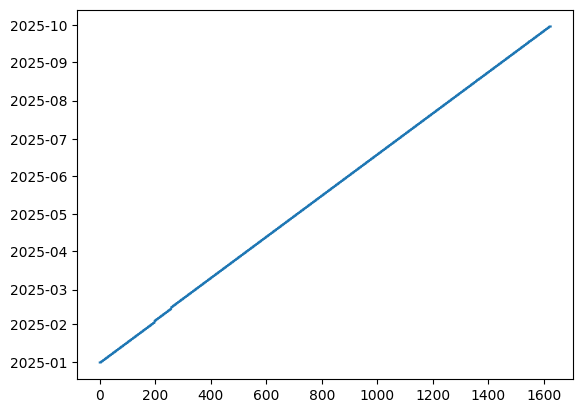

In [8]:
feeding_daily_corral["date"].plot()

<Axes: title={'center': 'Valores NaN por hoja'}, xlabel='Hojas', ylabel='Cantidad de NaN'>

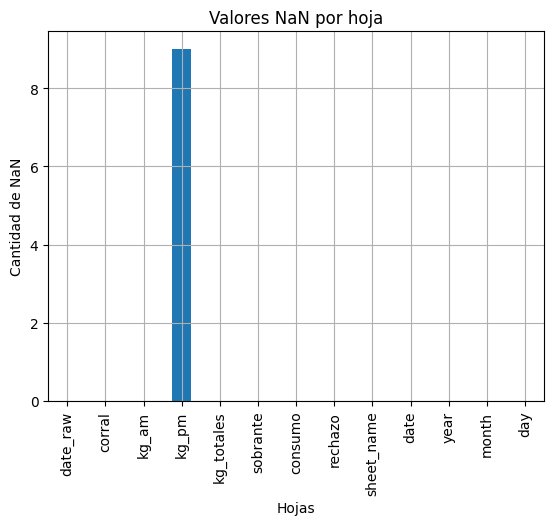

In [9]:
feeding_daily_corral.isna().sum().plot(kind="bar", title="Valores NaN por hoja", ylabel="Cantidad de NaN", xlabel="Hojas", grid=True)

In [10]:

cols_order = [
    "date", "year", "month", "day", "corral",
    "kg_am", "kg_pm", "kg_totales", "sobrante", "consumo", "rechazo",
    "sheet_name"
]

feeding_daily_corral = feeding_daily_corral[[c for c in cols_order if c in feeding_daily_corral.columns]].copy()

print("Columnas finales feeding_daily_corral:", feeding_daily_corral.columns.tolist())
feeding_daily_corral.head()


Columnas finales feeding_daily_corral: ['date', 'year', 'month', 'day', 'corral', 'kg_am', 'kg_pm', 'kg_totales', 'sobrante', 'consumo', 'rechazo', 'sheet_name']


,date,year,month,day,corral,kg_am,kg_pm,kg_totales,sobrante,consumo,rechazo,sheet_name
0,2025-01-01,2025,1,1,1,500.0,500.0,1000,0.0,1000,0.000000,Enero
1,2025-01-01,2025,1,1,2,650.0,650.0,1300,0.0,1300,0.000000,Enero
2,2025-01-01,2025,1,1,3,600.0,600.0,1200,0.0,1200,0.000000,Enero
3,2025-01-01,2025,1,1,4,650.0,650.0,1300,10.0,1290,0.007692,Enero
4,2025-01-01,2025,1,1,5,600.0,600.0,1200,0.0,1200,0.000000,Enero


In [11]:
if "pct_rechazo" in feeding_daily_corral.columns:
    feeding_daily_corral = feeding_daily_corral.drop(columns=["pct_rechazo"])

feeding_daily_corral["sobrante"] = pd.to_numeric(
    feeding_daily_corral["sobrante"], errors="coerce"
)
feeding_daily_corral["kg_totales"] = pd.to_numeric(
    feeding_daily_corral["kg_totales"], errors="coerce"
)

feeding_daily_corral = feeding_daily_corral.dropna(
    subset=["sobrante", "kg_totales"]
).copy()

feeding_daily_corral["rechazo"] = np.where(
    feeding_daily_corral["kg_totales"].astype(float) == 0,
    0.0,
    feeding_daily_corral["sobrante"].astype(float) / feeding_daily_corral["kg_totales"].astype(float) * 100.0
)

feeding_daily_corral["rechazo"] = pd.to_numeric(
    feeding_daily_corral["rechazo"],
    errors="coerce"
).fillna(0.0)

feeding_daily_corral.head()

,date,year,month,day,corral,kg_am,kg_pm,kg_totales,sobrante,consumo,rechazo,sheet_name
0,2025-01-01,2025,1,1,1,500.0,500.0,1000,0.0,1000,0.000000,Enero
1,2025-01-01,2025,1,1,2,650.0,650.0,1300,0.0,1300,0.000000,Enero
2,2025-01-01,2025,1,1,3,600.0,600.0,1200,0.0,1200,0.000000,Enero
3,2025-01-01,2025,1,1,4,650.0,650.0,1300,10.0,1290,0.769231,Enero
4,2025-01-01,2025,1,1,5,600.0,600.0,1200,0.0,1200,0.000000,Enero


In [12]:
# renombrar la columna y asegurarnos de que sea un entero
if "corrales" in feeding_daily_corral.columns:
    feeding_daily_corral = feeding_daily_corral.rename(columns={"corrales": "corral"})
    # convertir a numérico y luego a entero (Int64 para mantener NAs si los hay)
    feeding_daily_corral["corral"] = (
        pd.to_numeric(feeding_daily_corral["corral"], errors="coerce")
          .astype("Int64")
    )

# actualizar la variable si la usamos más adelante
corral_col = "corral"

feeding_daily_corral.head()

,date,year,month,day,corral,kg_am,kg_pm,kg_totales,sobrante,consumo,rechazo,sheet_name
0,2025-01-01,2025,1,1,1,500.0,500.0,1000,0.0,1000,0.000000,Enero
1,2025-01-01,2025,1,1,2,650.0,650.0,1300,0.0,1300,0.000000,Enero
2,2025-01-01,2025,1,1,3,600.0,600.0,1200,0.0,1200,0.000000,Enero
3,2025-01-01,2025,1,1,4,650.0,650.0,1300,10.0,1290,0.769231,Enero
4,2025-01-01,2025,1,1,5,600.0,600.0,1200,0.0,1200,0.000000,Enero


### Comentarios y observaciones

En esta etapa conviene revisar:

- si todas las hojas se leyeron
- si `date` y `corral_id` quedaron bien pobladas
- si los nombres de columnas quedaron homogéneos
- si existen cambios de formato entre meses

Las hojas mensuales pueden tener encabezados ligeramente distintos, por eso este parser intenta ser tolerante.


## 7. Limpieza adicional y variables derivadas de alimentación


In [13]:
feeding_daily_corral = feeding_daily_corral.dropna(subset=["date", "corral"]).copy()

print("Shape después de limpieza:", feeding_daily_corral.shape)
display(feeding_daily_corral.head(20))


Shape después de limpieza: (1626, 12)


,date,year,month,day,corral,kg_am,kg_pm,kg_totales,sobrante,consumo,rechazo,sheet_name
0,2025-01-01,2025,1,1,1,500.0,500.0,1000,0.0,1000,0.000000,Enero
1,2025-01-01,2025,1,1,2,650.0,650.0,1300,0.0,1300,0.000000,Enero
2,2025-01-01,2025,1,1,3,600.0,600.0,1200,0.0,1200,0.000000,Enero
3,2025-01-01,2025,1,1,4,650.0,650.0,1300,10.0,1290,0.769231,Enero
4,2025-01-01,2025,1,1,5,600.0,600.0,1200,0.0,1200,0.000000,Enero
5,2025-01-01,2025,1,1,6,1000.0,1000.0,2000,0.0,2000,0.000000,Enero
6,2025-01-02,2025,1,2,1,550.0,550.0,1100,110.0,990,10.000000,Enero
7,2025-01-02,2025,1,2,2,650.0,650.0,1300,130.0,1170,10.000000,Enero
8,2025-01-02,2025,1,2,3,600.0,600.0,1200,80.0,1120,6.666667,Enero
9,2025-01-02,2025,1,2,4,650.0,650.0,1300,220.0,1080,16.923077,Enero


## 8. Revisión rápida del dataset diario por corral


In [14]:
print("Rango de fechas:", feeding_daily_corral["date"].min(), "->", feeding_daily_corral["date"].max())
print("Número de corrales:", feeding_daily_corral["corral"].nunique())
print("Fechas únicas:", feeding_daily_corral["date"].nunique())

display(
    feeding_daily_corral.groupby(feeding_daily_corral["date"].dt.to_period("M"))["date"].nunique()
)

# QA adicional: confirmar que el mes coincide con la hoja
qa_month_map = {k.strip().lower(): v for k, v in month_map.items()}
qa = feeding_daily_corral.copy()
qa["sheet_month"] = qa["sheet_name"].astype(str).str.strip().str.lower().map(qa_month_map)

qa_mismatch = qa[
    qa["sheet_month"].notna() &
    (qa["date"].dt.month != qa["sheet_month"])
].copy()

print("Inconsistencias restantes fecha-hoja:", len(qa_mismatch))
if len(qa_mismatch):
    display(qa_mismatch[["date_raw", "date", "sheet_name", "corral"]].head(20))

Rango de fechas: 2025-01-01 00:00:00 -> 2025-09-30 00:00:00
Número de corrales: 6
Fechas únicas: 271


date
2025-01    31
2025-02    26
2025-03    31
2025-04    30
2025-05    31
2025-06    30
2025-07    31
2025-08    31
2025-09    30
Freq: M, Name: date, dtype: int64

Inconsistencias restantes fecha-hoja: 0


### Comentarios y observaciones

Este dataset ya queda a nivel:

```text
date + corral_id
```

Todavía no está a nivel vaca.  
Para llevarlo al entrenamiento por vaca será necesario un mapeo:

```text
cow_id + date -> corral_id
```

Si no se tiene ese mapeo, solo podrá unirse a nivel global por fecha o por grupo de vacas.


## 9. Lectura de hojas de dieta por periodo

Estas hojas no representan observaciones diarias, sino la dieta vigente en bloques temporales.

### Interpretación correcta

- `dieta Mayo` -> vigente de enero a mayo
- `Dieta Junio` -> vigente de junio a julio
- `Dieta Agosto` -> vigente de agosto a septiembre

A diferencia de las hojas mensuales, aquí se detecta de forma explícita la fila que contiene `INGREDIENTES`, porque ese es el encabezado real de la tabla.


In [15]:

diet_frames = []
diet_debug = []

for sheet, (start_date, end_date) in diet_periods_map.items():
    df, header_idx = parse_diet_sheet(INPUT_PATH, sheet, start_date, end_date)

    print(f"\nHoja: {sheet}")
    print("Fila de encabezado detectada:", header_idx)
    display(df)

    diet_frames.append(df)

    diet_debug.append({
        "sheet": sheet,
        "header_idx": header_idx,
        "rows": len(df),
        "period_start": pd.to_datetime(start_date),
        "period_end": pd.to_datetime(end_date),
        "consumo_kg_vaca": df["consumo_kg_vaca"].iloc[0] if len(df) else np.nan,
        "am_pm_fraction": df["am_pm_fraction"].iloc[0] if len(df) else np.nan
    })

diet_debug_df = pd.DataFrame(diet_debug)
display(diet_debug_df)

diet_periods = pd.concat(diet_frames, ignore_index=True)
diet_periods = diet_periods.sort_values(["period_start", "ingrediente"]).reset_index(drop=True)

print("Shape diet_periods:", diet_periods.shape)
display(diet_periods)



Hoja: dieta Mayo
Fila de encabezado detectada: 4


,ingrediente,pct_ms,kg_humeda,kg_seca,kg_am_pm,diet_period,period_start,period_end,consumo_kg_vaca,am_pm_fraction
0,TRITICALE,0.310,25.16,7.7996,1937.32,dieta Mayo,2025-01-01,2025-05-31,154,0.5
1,PATA DE CEBADA,0.880,0.46,0.4048,35.42,dieta Mayo,2025-01-01,2025-05-31,154,0.5
2,ORO MILK,0.900,15.76,14.1840,1213.52,dieta Mayo,2025-01-01,2025-05-31,154,0.5
3,Melaza(50% Agua),0.400,3.33,1.3320,256.41,dieta Mayo,2025-01-01,2025-05-31,154,0.5
4,Agua,0.001,5.50,0.0055,423.50,dieta Mayo,2025-01-01,2025-05-31,154,0.5



Hoja: Dieta Junio
Fila de encabezado detectada: 3


,ingrediente,pct_ms,kg_humeda,kg_seca,kg_am_pm,diet_period,period_start,period_end,consumo_kg_vaca,am_pm_fraction
0,TRITICALE,0.310,32.26,10.0006,2645.32,Dieta Junio,2025-06-01,2025-07-31,164,0.5
1,PATA DE CEBADA,0.880,0.34,0.2992,27.88,Dieta Junio,2025-06-01,2025-07-31,164,0.5
2,ORO Balance,0.900,4.42,3.9780,362.44,Dieta Junio,2025-06-01,2025-07-31,164,0.5
3,ORO MILK,0.900,8.70,7.8300,713.40,Dieta Junio,2025-06-01,2025-07-31,164,0.5
4,Melaza(50% Agua),0.370,3.73,1.3801,305.86,Dieta Junio,2025-06-01,2025-07-31,164,0.5
5,Agua,0.001,3.00,0.0030,246.00,Dieta Junio,2025-06-01,2025-07-31,164,0.5



Hoja: Dieta Agosto
Fila de encabezado detectada: 3


,ingrediente,pct_ms,kg_humeda,kg_seca,kg_am_pm,diet_period,period_start,period_end,consumo_kg_vaca,am_pm_fraction
0,SILO DE AVENA,0.310,28.29,8.7699,2263.2,Dieta Agosto,2025-08-01,2025-09-30,160,0.5
1,silo de MAIZ,0.340,5.88,1.9992,470.4,Dieta Agosto,2025-08-01,2025-09-30,160,0.5
2,PATA DE CEBADA,0.880,0.34,0.2992,27.2,Dieta Agosto,2025-08-01,2025-09-30,160,0.5
3,MAIZ MOLIDO,0.870,2.30,2.0010,184.0,Dieta Agosto,2025-08-01,2025-09-30,160,0.5
4,Pasta se SOYA,0.900,0.56,0.5040,44.8,Dieta Agosto,2025-08-01,2025-09-30,160,0.5
5,ORO Balance,0.900,3.31,2.9790,264.8,Dieta Agosto,2025-08-01,2025-09-30,160,0.5
6,ORO MILK,0.900,7.61,6.8490,608.8,Dieta Agosto,2025-08-01,2025-09-30,160,0.5
7,Melaza(50% Agua),0.370,3.73,1.3801,298.4,Dieta Agosto,2025-08-01,2025-09-30,160,0.5
8,Agua,0.001,2.00,0.0020,160.0,Dieta Agosto,2025-08-01,2025-09-30,160,0.5


,sheet,header_idx,rows,period_start,period_end,consumo_kg_vaca,am_pm_fraction
0,dieta Mayo,4,5,2025-01-01,2025-05-31,154,0.5
1,Dieta Junio,3,6,2025-06-01,2025-07-31,164,0.5
2,Dieta Agosto,3,9,2025-08-01,2025-09-30,160,0.5


Shape diet_periods: (20, 10)


,ingrediente,pct_ms,kg_humeda,kg_seca,kg_am_pm,diet_period,period_start,period_end,consumo_kg_vaca,am_pm_fraction
0,Agua,0.001,5.50,0.0055,423.50,dieta Mayo,2025-01-01,2025-05-31,154,0.5
1,Melaza(50% Agua),0.400,3.33,1.3320,256.41,dieta Mayo,2025-01-01,2025-05-31,154,0.5
2,ORO MILK,0.900,15.76,14.1840,1213.52,dieta Mayo,2025-01-01,2025-05-31,154,0.5
3,PATA DE CEBADA,0.880,0.46,0.4048,35.42,dieta Mayo,2025-01-01,2025-05-31,154,0.5
4,TRITICALE,0.310,25.16,7.7996,1937.32,dieta Mayo,2025-01-01,2025-05-31,154,0.5
5,Agua,0.001,3.00,0.0030,246.00,Dieta Junio,2025-06-01,2025-07-31,164,0.5
6,Melaza(50% Agua),0.370,3.73,1.3801,305.86,Dieta Junio,2025-06-01,2025-07-31,164,0.5
7,ORO Balance,0.900,4.42,3.9780,362.44,Dieta Junio,2025-06-01,2025-07-31,164,0.5
8,ORO MILK,0.900,8.70,7.8300,713.40,Dieta Junio,2025-06-01,2025-07-31,164,0.5
9,PATA DE CEBADA,0.880,0.34,0.2992,27.88,Dieta Junio,2025-06-01,2025-07-31,164,0.5


## 10. Resumen de dieta por periodo


In [16]:

summary_rows = []

for period_name, g in diet_periods.groupby("diet_period"):
    row = {
        "diet_period": period_name,
        "period_start": g["period_start"].iloc[0],
        "period_end": g["period_end"].iloc[0],
        "consumo_kg_vaca": g["consumo_kg_vaca"].iloc[0],
        "am_pm_fraction": g["am_pm_fraction"].iloc[0],
        "n_ingredientes": g["ingrediente"].nunique(),
        "diet_dm_total": g["kg_seca"].sum(skipna=True),
        "diet_wet_total": g["kg_humeda"].sum(skipna=True),
        "diet_pct_ms_total": g["pct_ms"].sum(skipna=True),
    }

    ingredient_list = g["ingrediente"].dropna().astype(str).str.lower().tolist()

    for key, token in {
        "usa_oro_milk": "oro milk",
        "usa_oro_balance": "oro balance",
        "usa_silo_maiz": "maiz",
        "usa_silo_avena": "avena",
        "usa_ensilado": "ensil",
        "usa_heno": "heno",
        "usa_triticale": "triticale",
        "usa_melaza": "melaza",
        "usa_soya": "soya",
    }.items():
        row[key] = int(any(token in ing for ing in ingredient_list))

    summary_rows.append(row)

diet_period_summary = pd.DataFrame(summary_rows).sort_values("period_start").reset_index(drop=True)
display(diet_period_summary)


,diet_period,period_start,period_end,consumo_kg_vaca,am_pm_fraction,n_ingredientes,diet_dm_total,diet_wet_total,diet_pct_ms_total,usa_oro_milk,usa_oro_balance,usa_silo_maiz,usa_silo_avena,usa_ensilado,usa_heno,usa_triticale,usa_melaza,usa_soya
0,dieta Mayo,2025-01-01,2025-05-31,154,0.5,5,23.7259,50.21,2.491,1,0,0,0,0,0,1,1,0
1,Dieta Junio,2025-06-01,2025-07-31,164,0.5,6,23.4909,52.45,3.361,1,1,0,0,0,0,1,1,0
2,Dieta Agosto,2025-08-01,2025-09-30,160,0.5,9,24.7834,54.02,5.471,1,1,1,1,0,0,0,1,1


### Comentarios y observaciones

Este resumen no reemplaza la tabla detallada de ingredientes, pero sí facilita mucho el uso de la dieta como variable de periodo dentro del modelo.


## 11. Guardado a parquet


In [17]:

Path(OUT_FEEDING).parent.mkdir(parents=True, exist_ok=True)

def safe_save_dataframe(df, parquet_path):
    try:
        df.to_parquet(parquet_path, index=False)
        print("Guardado parquet:", parquet_path)
    except Exception as e:
        csv_path = str(Path(parquet_path).with_suffix(".csv"))
        df.to_csv(csv_path, index=False)
        print("No se pudo guardar parquet.")
        print("Error:", e)
        print("Se guardó CSV alternativo:", csv_path)

safe_save_dataframe(feeding_daily_corral, OUT_FEEDING)
safe_save_dataframe(diet_periods, OUT_DIETS)
safe_save_dataframe(diet_period_summary, OUT_DIET_SUMMARY)


Guardado parquet: ../data/interim/feeding_daily_corral.parquet
Guardado parquet: ../data/interim/diet_periods.parquet
Guardado parquet: ../data/interim/diet_period_summary.parquet


## 12. Conclusiones

En este notebook se construyeron tres datasets útiles:

### 1. `feeding_daily_corral`
Observaciones diarias por fecha y corral, útiles para modelar oferta, consumo, sobrante y rechazo.

### 2. `diet_periods`
Tabla detallada de ingredientes por periodo de dieta vigente.

### 3. `diet_period_summary`
Resumen compacto por periodo, útil para merges posteriores y creación de features.

## Observación importante

Para usar estos datos dentro del dataset de entrenamiento por vaca se necesitará:

- un mapeo vaca -> corral por fecha, o
- una agregación global por fecha si no existe ese mapeo.

## Mejora aplicada en esta versión

Las hojas de dieta ahora se leen buscando explícitamente la fila donde aparece `INGREDIENTES`, evitando que el encabezado se interprete mal y dejando de generar tablas vacías.

## Próximos pasos sugeridos

1. validar columnas reales de cada hoja mensual  
2. revisar si todos los corrales quedaron bien parseados  
3. integrar `feeding_daily_corral` al pipeline principal  
4. construir features de alimentación para el entrenamiento
